In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
PROJECT_PATH = r"C:\Users\abc\projects\Cancer Cell Classification Project"

DATA_DIR = os.path.join(PROJECT_PATH, "Data")
FIGURES_DIR = os.path.join(PROJECT_PATH, "Figures")
NOTEBOOKS_DIR = os.path.join(PROJECT_PATH, "Notebooks")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(NOTEBOOKS_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)

DATA_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Data
FIGURES_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Figures
NOTEBOOKS_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks


In [5]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (630, 128, 128, 3)
X_test shape: (158, 128, 128, 3)
y_train shape: (630,)
y_test shape: (158,)


In [7]:
df = pd.read_csv(os.path.join(DATA_DIR, "expanded_dataset.csv"))

encoder = LabelEncoder()
encoder.fit(df["moa"])

class_names = list(encoder.classes_)
num_classes = len(class_names)

print("Encoded class order:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", num_classes)

Encoded class order:
0: Aurora kinase inhibitors
1: DNA damage
2: Eg5 inhibitors
3: Microtubule destabilizers
4: Microtubule stabilizers
Number of classes: 5


In [9]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_train_main shape:", X_train_main.shape)
print("X_val shape:", X_val.shape)
print("y_train_main shape:", y_train_main.shape)
print("y_val shape:", y_val.shape)

X_train_main shape: (504, 128, 128, 3)
X_val shape: (126, 128, 128, 3)
y_train_main shape: (504,)
y_val shape: (126,)


In [11]:
print("Training subset class distribution:")
train_unique, train_counts = np.unique(y_train_main, return_counts=True)
for cls, count in zip(train_unique, train_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

print("\nValidation subset class distribution:")
val_unique, val_counts = np.unique(y_val, return_counts=True)
for cls, count in zip(val_unique, val_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

print("\nTest set class distribution:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for cls, count in zip(test_unique, test_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

Training subset class distribution:
Class 0 (Aurora kinase inhibitors): 46
Class 1 (DNA damage): 69
Class 2 (Eg5 inhibitors): 54
Class 3 (Microtubule destabilizers): 90
Class 4 (Microtubule stabilizers): 245

Validation subset class distribution:
Class 0 (Aurora kinase inhibitors): 12
Class 1 (DNA damage): 17
Class 2 (Eg5 inhibitors): 13
Class 3 (Microtubule destabilizers): 22
Class 4 (Microtubule stabilizers): 62

Test set class distribution:
Class 0 (Aurora kinase inhibitors): 14
Class 1 (DNA damage): 22
Class 2 (Eg5 inhibitors): 17
Class 3 (Microtubule destabilizers): 28
Class 4 (Microtubule stabilizers): 77


In [13]:
classes = np.unique(y_train_main)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_main
)

class_weights = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}

print("Class weights:")
for cls, weight in class_weights.items():
    print(f"Class {cls} ({class_names[cls]}): {weight:.4f}")

Class weights:
Class 0 (Aurora kinase inhibitors): 2.1913
Class 1 (DNA damage): 1.4609
Class 2 (Eg5 inhibitors): 1.8667
Class 3 (Microtubule destabilizers): 1.1200
Class 4 (Microtubule stabilizers): 0.4114


In [15]:
X_train_main_resnet = preprocess_input(X_train_main * 255.0)
X_val_resnet = preprocess_input(X_val * 255.0)
X_test_resnet = preprocess_input(X_test * 255.0)

print("ResNet preprocessing complete.")
print("X_train_main_resnet shape:", X_train_main_resnet.shape)
print("X_val_resnet shape:", X_val_resnet.shape)
print("X_test_resnet shape:", X_test_resnet.shape)

ResNet preprocessing complete.
X_train_main_resnet shape: (504, 128, 128, 3)
X_val_resnet shape: (126, 128, 128, 3)
X_test_resnet shape: (158, 128, 128, 3)


In [17]:
y_train_main_cat = to_categorical(y_train_main, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_main_cat shape:", y_train_main_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

y_train_main_cat shape: (504, 5)
y_val_cat shape: (126, 5)
y_test_cat shape: (158, 5)


In [19]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(128, 128, 3))
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 model compiled successfully.")

ResNet50 model compiled successfully.


In [23]:
best_model_path = os.path.join(NOTEBOOKS_DIR, "best_resnet50_transfer_model.keras")

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [25]:
history = model.fit(
    X_train_main_resnet,
    y_train_main_cat,
    validation_data=(X_val_resnet, y_val_cat),
    epochs=25,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25


C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.1605 - loss: 1.9181
Epoch 1: val_loss improved from inf to 1.10080, saving model to C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_resnet50_transfer_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 558ms/step - accuracy: 0.1622 - loss: 1.9124 - val_accuracy: 0.5000 - val_loss: 1.1008 - learning_rate: 1.0000e-04
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.4710 - loss: 1.1768
Epoch 2: val_loss improved from 1.10080 to 0.87491, saving model to C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_resnet50_transfer_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 443ms/step - accuracy: 0.4721 - loss: 1.1774 - val_accuracy: 0.7460 - val_loss: 0.8749 - learning_rate: 1.0000e-04
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5650 - loss: 1.0395
Epoch 3: val_loss improved from 0.87491 to 0.76195, saving model to C:\Users\abc\projects\Cancer Cell Classification Project\

In [27]:
final_model_path = os.path.join(NOTEBOOKS_DIR, "final_resnet50_transfer_model.keras")
model.save(final_model_path)

print("Best model saved to:", best_model_path)
print("Final model saved to:", final_model_path)

Best model saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_resnet50_transfer_model.keras
Final model saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\final_resnet50_transfer_model.keras


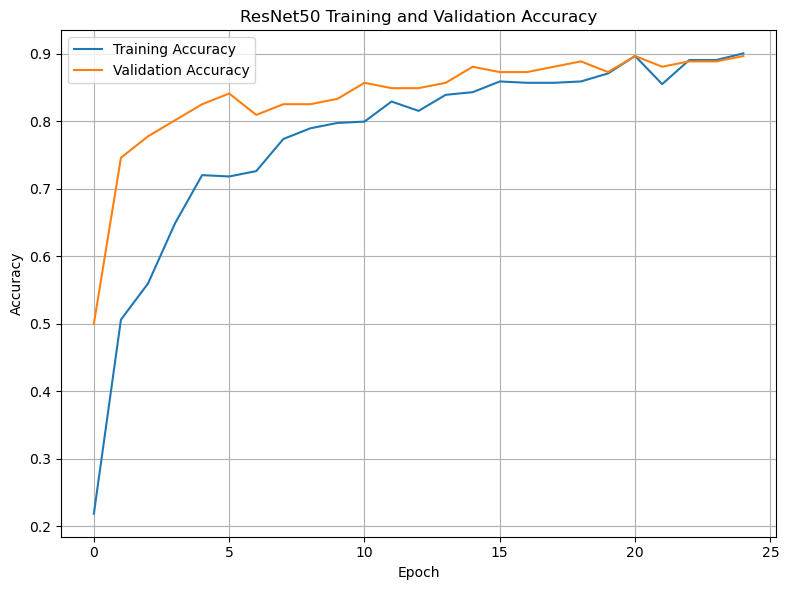

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_training_validation_accuracy.png


In [29]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_fig_path = os.path.join(FIGURES_DIR, "resnet50_training_validation_accuracy.png")
plt.savefig(accuracy_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", accuracy_fig_path)

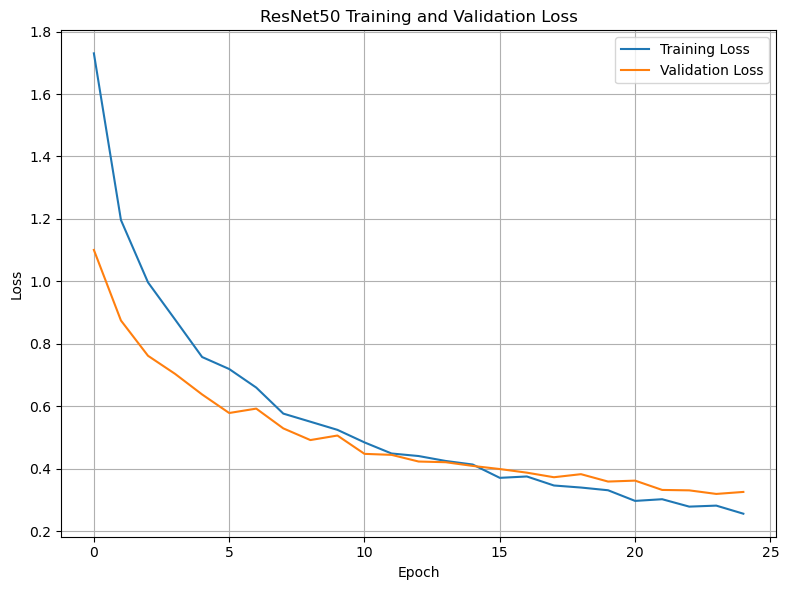

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_training_validation_loss.png


In [31]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = os.path.join(FIGURES_DIR, "resnet50_training_validation_loss.png")
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", loss_fig_path)

In [33]:
test_loss, test_accuracy = model.evaluate(X_test_resnet, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3818
Test Accuracy: 0.8734


In [35]:
y_pred_probs = model.predict(X_test_resnet)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Prediction complete.")
print("y_pred shape:", y_pred.shape)

C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 128, 128, 3))
  warnings.warn(msg)


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step

C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  
Prediction complete.
y_pred shape: (158,)


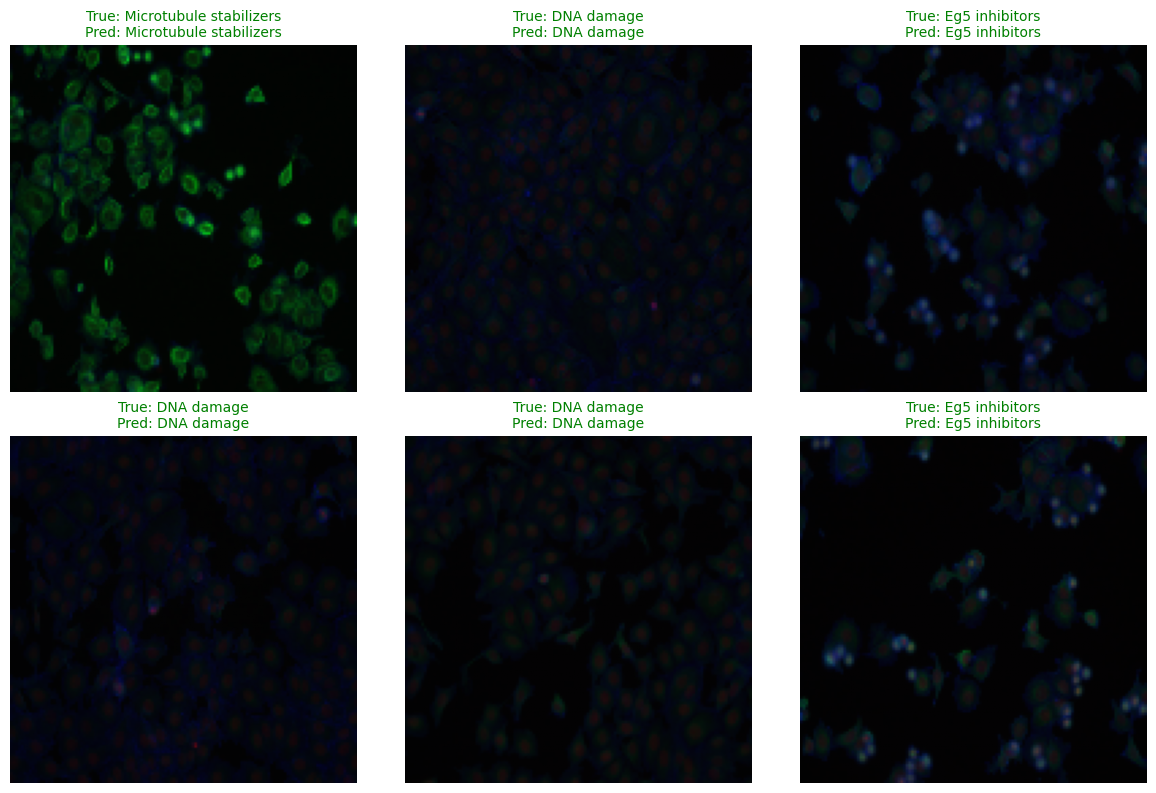

Sample predictions saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_sample_predictions.png


In [49]:
import random

# Number of random samples to display
num_samples = 6

indices = random.sample(range(len(X_test)), num_samples)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = X_test[idx]  # original (0–1 scaled image)
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}",
              color="green" if true_label == pred_label else "red",
              fontsize=10)
    plt.axis("off")

plt.tight_layout()

# Save figure
sample_fig_path = os.path.join(FIGURES_DIR, "resnet50_sample_predictions.png")
plt.savefig(sample_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Sample predictions saved to:", sample_fig_path)

In [37]:
test_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

Test Accuracy: 0.8734
Macro F1 Score: 0.8802


In [39]:
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

                           precision    recall  f1-score   support

 Aurora kinase inhibitors       1.00      1.00      1.00        14
               DNA damage       1.00      0.95      0.98        22
           Eg5 inhibitors       0.64      0.82      0.72        17
Microtubule destabilizers       0.74      0.93      0.83        28
  Microtubule stabilizers       0.95      0.82      0.88        77

                 accuracy                           0.87       158
                macro avg       0.87      0.90      0.88       158
             weighted avg       0.89      0.87      0.88       158



In [41]:
report_path = os.path.join(FIGURES_DIR, "resnet50_classification_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("ResNet50 Transfer Learning Classification Report\n")
    f.write("===============================================\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n\n")
    f.write(report)

print("Classification report saved to:", report_path)

Classification report saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_classification_report.txt


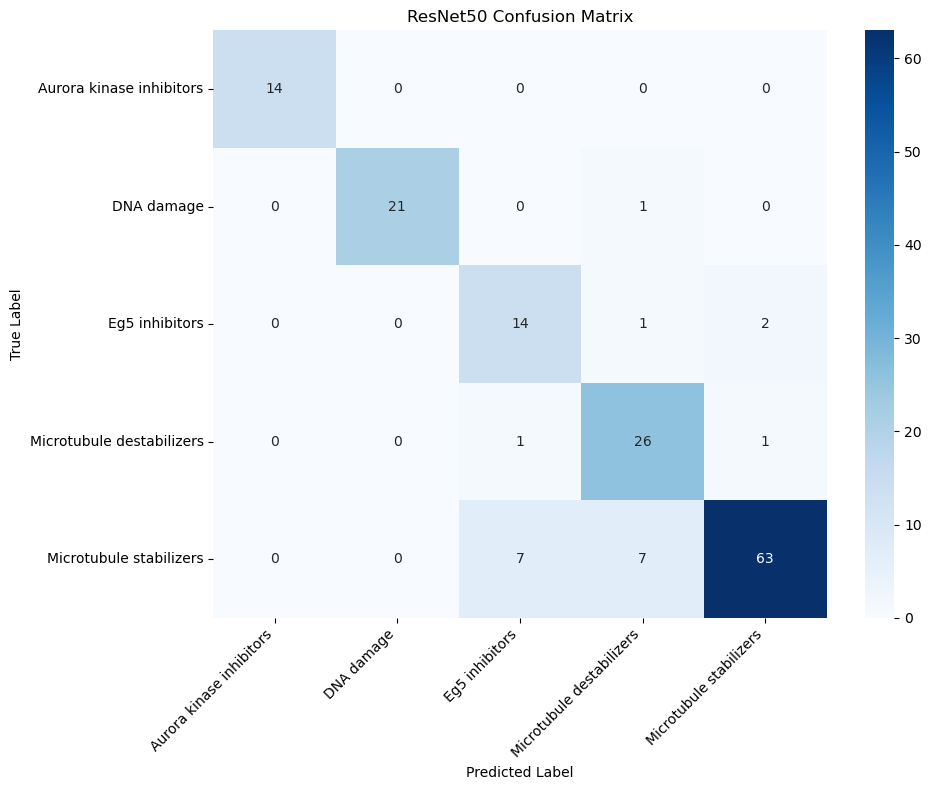

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_confusion_matrix.png


In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_fig_path = os.path.join(FIGURES_DIR, "resnet50_confusion_matrix.png")
plt.savefig(cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", cm_fig_path)

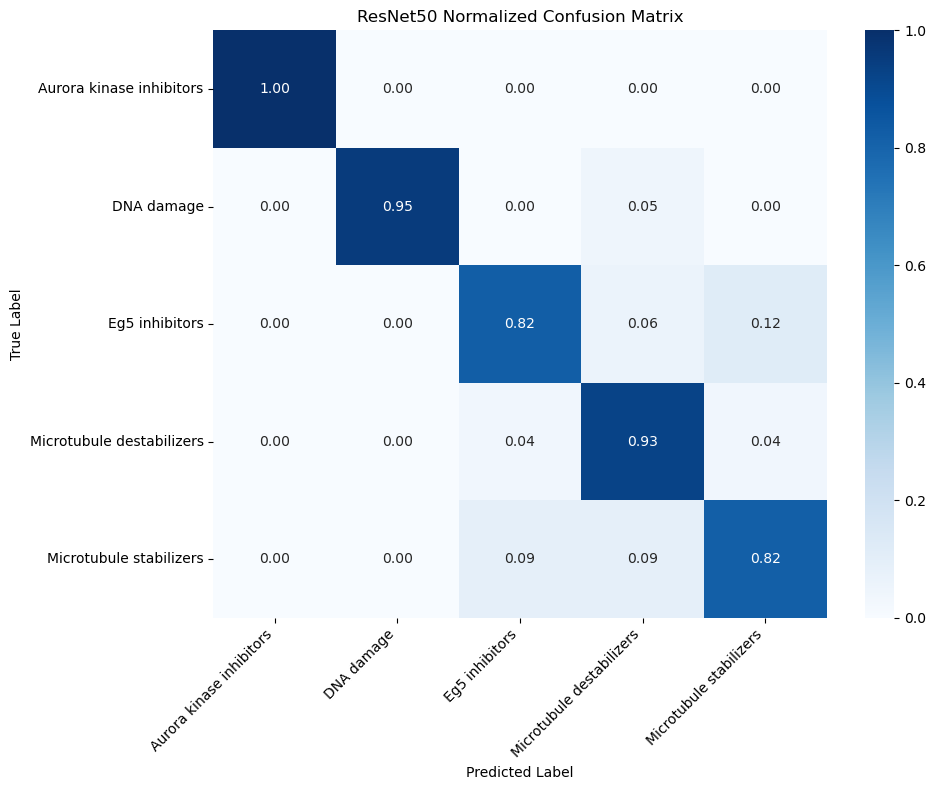

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_normalized_confusion_matrix.png


In [45]:
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet50 Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_fig_path = os.path.join(FIGURES_DIR, "resnet50_normalized_confusion_matrix.png")
plt.savefig(cm_norm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", cm_norm_fig_path)

In [47]:
summary_results_path = os.path.join(FIGURES_DIR, "resnet50_evaluation_summary.txt")

with open(summary_results_path, "w", encoding="utf-8") as f:
    f.write("ResNet50 Transfer Learning Evaluation Summary\n")
    f.write("============================================\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n")
    f.write(f"Number of Test Samples: {len(y_test)}\n")
    f.write(f"Number of Classes: {num_classes}\n\n")
    f.write("Class Names:\n")
    for i, name in enumerate(class_names):
        f.write(f"{i}: {name}\n")

print("Summary saved to:", summary_results_path)

Summary saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_evaluation_summary.txt
